# Dev/09 Aperture Layer Tests

This notebook validates the read-only aperture layer using real MAD-X TWISS/APERTURE output and the ISIS source aperture spreadsheet copied from `isis_2024`. It shows the GUI-facing view: aperture, closed orbit, envelope, and limiting clearance margin.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cycle_time import RCSRamp
from errors import write_error_table
from machine_state import MachineState
from orbit_branch import OrbitBranch, OrbitBranchConfig
from tune_matching import normalise_harmonic_inputs
from envelope import EnvelopeInputs, evaluate_envelope_from_machine_state, evaluate_envelope_from_twiss
from aperture import (
    read_source_aperture_csv,
    normalise_madx_aperture_table,
    extract_madx_aperture_from_machine_state,
    evaluate_aperture_margins,
    compare_aperture_summaries,
    plot_aperture_envelope,
    plot_aperture_envelope_with_margin,
    plot_aperture_source_overlay,
    plot_margin,
)
from madx_model import MadxModel

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (11, 4)

## Build nominal, harmonic and distorted machine states

The aperture workflow consumes envelope results. This notebook uses the repository-local simplified lattice as the starting lattice and plots a 1 sigma envelope with 300 pi mm mrad emittance and 0.2% momentum spread. The sigma scale remains an explicit user input for the future GUI.

In [2]:
LATTICE_FOLDER = "../Lattice_Files/00_Simplified_Lattice"
APERTURE_FILE = "ISIS.aperture"
OUTPUT_DIR = Path("aperture_tests")
CYCLE_TIME_MS = 2.5

beam_state = RCSRamp().state_at(CYCLE_TIME_MS)

nominal_state = MachineState.from_defaults(
    beam_state=beam_state,
    metadata={"case": "nominal_aperture"},
)

large_harmonics = normalise_harmonic_inputs(
    {
        "D7SIN": 20.0,
        "F8SIN": 20.0,
    }
)
harmonic_state = MachineState.from_defaults(
    beam_state=beam_state,
    harmonic_tunes=large_harmonics,
    metadata={"case": "large_harmonic_aperture"},
)

inputs_nominal = EnvelopeInputs(label="nominal", sigma_scale=1.0)
inputs_harmonic = EnvelopeInputs(label="large harmonics", sigma_scale=1.0)

beam_state.summary_dict(), dict(large_harmonics)

({'cycle_time_ms': 2.5,
  'kinetic_energy_MeV': 139.03252304304772,
  'kinetic_energy_GeV': 0.13903252304304772,
  'total_energy_MeV': 1077.3046112030477,
  'total_energy_GeV': 1.0773046112030478,
  'gamma': 1.1481793232448145,
  'beta': 0.4913821178913615,
  'momentum_MeV_c': 529.3682214670833,
  'momentum_GeV_c': 0.5293682214670834,
  'brho_Tm': 1.7657823182032266,
  'normalised_momentum': 1.434091013579428},
 {'D7SIN': 20.0,
  'D7COS': 0.0,
  'D8SIN': 0.0,
  'D8COS': 0.0,
  'F8SIN': 20.0,
  'F8COS': 0.0,
  'F9SIN': 0.0,
  'F9COS': 0.0})

## Run real MAD-X envelopes

In [3]:
nominal_envelope = evaluate_envelope_from_machine_state(
    nominal_state,
    lattice_folder=LATTICE_FOLDER,
    output_dir=str(OUTPUT_DIR / "nominal_envelope_madx"),
    inputs=inputs_nominal,
)

harmonic_envelope = evaluate_envelope_from_machine_state(
    harmonic_state,
    lattice_folder=LATTICE_FOLDER,
    output_dir=str(OUTPUT_DIR / "harmonic_envelope_madx"),
    inputs=inputs_harmonic,
)

nominal_envelope.summary_df

,label,plane,sigma_scale,dp_over_p,emittance_mode,emit_x_geometric_m_rad,emit_y_geometric_m_rad,max_sigma_mm,max_sigma_name,max_sigma_s_m,max_plus_mm,max_plus_name,max_plus_s_m,min_minus_mm,min_minus_name,min_minus_s_m
0,nominal,x,1.0,0.002,geometric,0.0003,0.0003,75.585265,sp8_qf:1,135.788356,75.585265,sp8_qf:1,135.788356,-75.585265,sp8_qf:1,135.788356
1,nominal,y,1.0,0.002,geometric,0.0003,0.0003,70.830435,sp8_qdfr4:1,133.840656,70.830435,sp8_qdfr4:1,133.840656,-70.830435,sp8_qdfr4:1,133.840656


## Add a real closed-orbit distortion branch

This uses a MAD-X `SETERR` table through `OrbitBranch`. The distorted TWISS table is then passed to the aperture layer via the envelope layer.

In [4]:
distortion_table = pd.DataFrame(
    [
        {
            "name": "sp0_qd:1",
            "dx": 1.0e-2,
            "dy": 1.0e-2,
            "ds": 0.0,
            "dphi": 0.0,
            "dtheta": 0.0,
            "dpsi": 0.0,
        }
    ]
)
distortion_path = write_error_table(
    distortion_table,
    OUTPUT_DIR / "closed_orbit_distortion_qd.tfs",
    table_name="CLOSED_ORBIT_DISTORTION_QD",
)

distorted_branch = OrbitBranch(
    OrbitBranchConfig(
        name="distorted_nominal",
        lattice_folder=LATTICE_FOLDER,
        machine_state=nominal_state,
        aperture_file=APERTURE_FILE,
        error_table_paths=[distortion_path],
        output_dir=OUTPUT_DIR / "distorted_nominal_branch",
        metadata={"case": "closed_orbit_distortion"},
    )
).run()

distorted_envelope = evaluate_envelope_from_twiss(
    distorted_branch.twiss_df,
    inputs=EnvelopeInputs(label="distorted orbit", sigma_scale=1.0),
    beam_state=beam_state,
    source="orbit_branch_distortion",
    metadata=distorted_branch.metadata,
)

distorted_envelope.summary_df

,label,plane,sigma_scale,dp_over_p,emittance_mode,emit_x_geometric_m_rad,emit_y_geometric_m_rad,max_sigma_mm,max_sigma_name,max_sigma_s_m,max_plus_mm,max_plus_name,max_plus_s_m,min_minus_mm,min_minus_name,min_minus_s_m
0,distorted orbit,x,1.0,0.002,geometric,0.0003,0.0003,76.068814,sp1_qf:1,21.434382,97.714943,sp6_qf:1,103.115792,-98.815987,sp5_qf:1,86.77951
1,distorted orbit,y,1.0,0.002,geometric,0.0003,0.0003,71.151399,sp0_qdfr4:1,3.150400,123.873013,sp9_qdfr4:1,150.176938,-124.690886,sp5_qdfr4:1,84.83181


## Extract MAD-X aperture and source-spreadsheet aperture

MAD-X aperture rows with zero half-aperture are ignored for margin calculations, because drifts cannot carry aperture metadata unless the lattice explicitly represents them as collimators. The source spreadsheet remains the authoritative aperture curve and is plotted alongside the MAD-X extracted table.

In [5]:
madx_aperture_extract = extract_madx_aperture_from_machine_state(
    nominal_state,
    lattice_folder=LATTICE_FOLDER,
    aperture_file=APERTURE_FILE,
    output_dir=str(OUTPUT_DIR / "madx_aperture"),
    interval=0.1,
)
madx_aperture_df = madx_aperture_extract.aperture_df
source_aperture_df = read_source_aperture_csv("aperture_data/jvt_synch_aperture.csv")

raw_simple_model = MadxModel(
    lattice_folder="../Lattice_Files/00_Simplified_Lattice",
    sequence_name="synchrotron",
    aperture_file="ISIS.aperture",
    output_dir=str(OUTPUT_DIR / "simple_lattice_zero_check"),
)
raw_simple_model.load_lattice(use_sequence=False)
raw_simple_model.apply_machine_state(nominal_state)
raw_simple_model.use_sequence()
raw_simple_aperture = raw_simple_model.run_aperture(interval=0.5)
zero_or_invalid_simple_rows = raw_simple_aperture[
    (pd.to_numeric(raw_simple_aperture["aper_1"], errors="coerce") <= 0.0)
    | (pd.to_numeric(raw_simple_aperture["aper_2"], errors="coerce") <= 0.0)
]
filtered_simple_aperture = normalise_madx_aperture_table(raw_simple_aperture)

pd.DataFrame(
    [
        {"source": "MAD-X APERTURE", "rows": len(madx_aperture_df), "min_x_mm": madx_aperture_df["aperture_x_mm"].min(), "min_y_mm": madx_aperture_df["aperture_y_mm"].min()},
        {"source": "source spreadsheet", "rows": len(source_aperture_df), "min_x_mm": source_aperture_df["aperture_x_mm"].min(), "min_y_mm": source_aperture_df["aperture_y_mm"].min()},
        {"source": "simple lattice zero/invalid rows", "rows": len(zero_or_invalid_simple_rows), "min_x_mm": np.nan, "min_y_mm": np.nan},
    ]
)

,source,rows,min_x_mm,min_y_mm
0,MAD-X APERTURE,1399,48.493276,54.895466
1,source spreadsheet,1740,48.493276,47.780884
2,simple lattice zero/invalid rows,150,NaN,NaN


## Compute aperture margins for MAD-X and source aperture data

In [6]:
madx_nominal_margin = evaluate_aperture_margins(
    madx_aperture_df,
    nominal_envelope,
    label="nominal MAD-X aperture",
    source="madx_aperture",
)
source_nominal_margin = evaluate_aperture_margins(
    source_aperture_df,
    nominal_envelope,
    label="nominal source aperture",
    source="source_spreadsheet",
)
source_harmonic_margin = evaluate_aperture_margins(
    source_aperture_df,
    harmonic_envelope,
    label="large harmonics source aperture",
    source="source_spreadsheet",
)
source_distorted_margin = evaluate_aperture_margins(
    source_aperture_df,
    distorted_envelope,
    label="distorted orbit source aperture",
    source="source_spreadsheet",
)

summary = compare_aperture_summaries(
    [
        madx_nominal_margin,
        source_nominal_margin,
        source_harmonic_margin,
        source_distorted_margin,
    ]
)
summary

,label,name,s_m,limiting_plane,limiting_side,margin_min_m,margin_min_mm,aperture_source,aperture_alignment
0,nominal MAD-X aperture,drift_93:0,134.668506,y,y_plus,0.010694,10.694149,madx_aperture,s_interpolated
1,nominal source aperture,sp3_dip:1,48.768846,y,y_plus,0.014401,14.401013,source_spreadsheet,s_interpolated
2,large harmonics source aperture,sp6_qtf:1,103.730492,y,y_plus,0.009239,9.238553,source_spreadsheet,s_interpolated
3,distorted orbit source aperture,sp5_qdfr4:1,84.831810,y,yinus,-0.032598,-32.597647,source_spreadsheet,s_interpolated


## MAD-X aperture table and source spreadsheet overlay

The source spreadsheet is plotted as an independent reference curve. Differences are expected where the MAD-X lattice has only element-level aperture metadata or where drifts cannot carry aperture values.

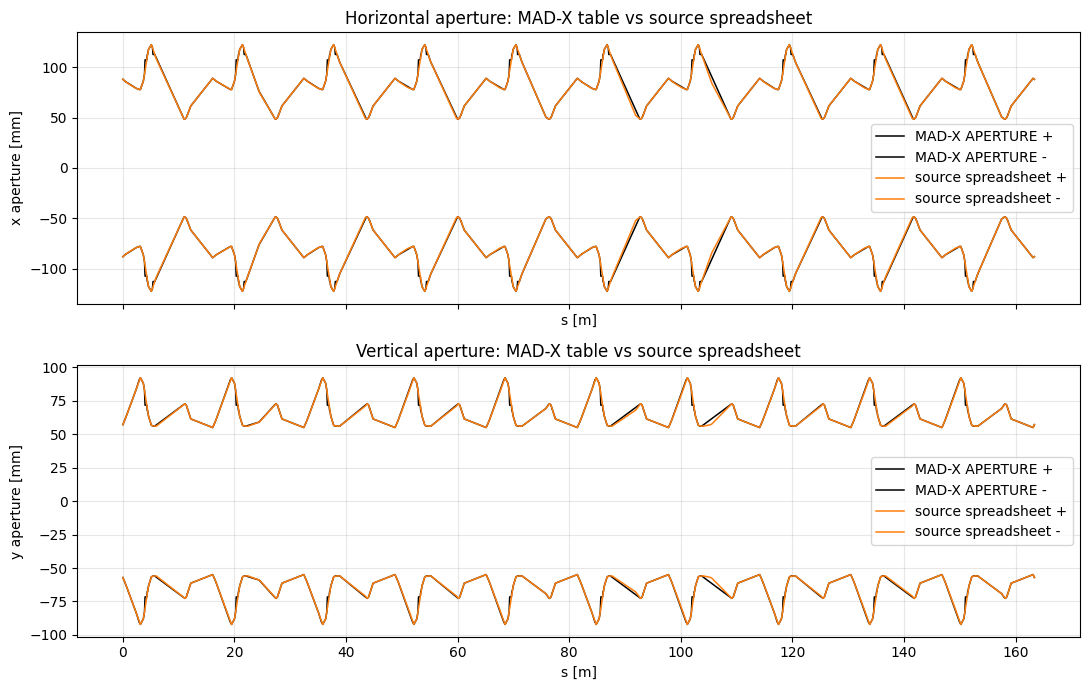

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
plot_aperture_source_overlay(madx_nominal_margin, source_nominal_margin, plane="x", ax=axes[0], title="Horizontal aperture: MAD-X table vs source spreadsheet")
plot_aperture_source_overlay(madx_nominal_margin, source_nominal_margin, plane="y", ax=axes[1], title="Vertical aperture: MAD-X table vs source spreadsheet")
plt.tight_layout()

## Aperture, closed orbit and envelope

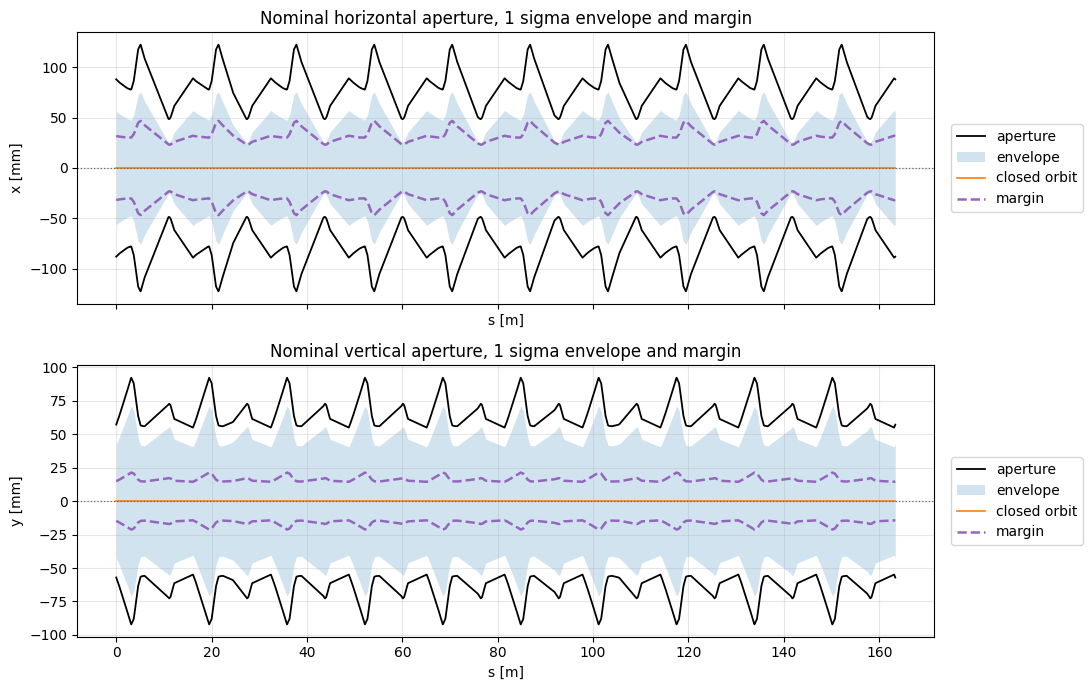

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
plot_aperture_envelope_with_margin(source_nominal_margin, plane="x", ax=axes[0], title="Nominal horizontal aperture, 1 sigma envelope and margin")
plot_aperture_envelope_with_margin(source_nominal_margin, plane="y", ax=axes[1], title="Nominal vertical aperture, 1 sigma envelope and margin")
plt.tight_layout()

## Margin changes with harmonics and closed-orbit distortion

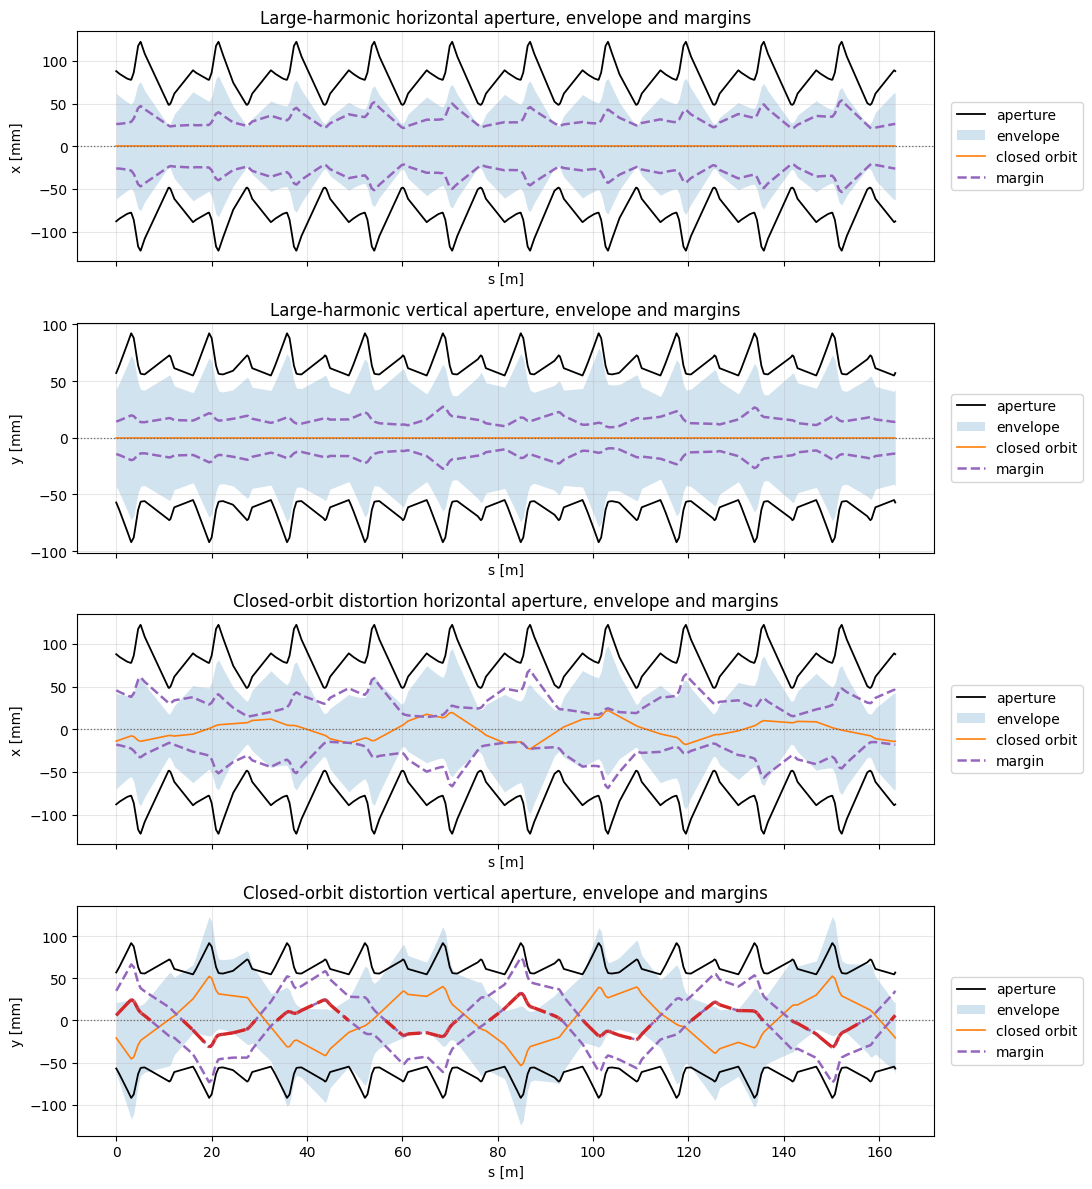

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)
plot_aperture_envelope_with_margin(source_harmonic_margin, plane="x", ax=axes[0], title="Large-harmonic horizontal aperture, envelope and margins")
plot_aperture_envelope_with_margin(source_harmonic_margin, plane="y", ax=axes[1], title="Large-harmonic vertical aperture, envelope and margins")
plot_aperture_envelope_with_margin(source_distorted_margin, plane="x", ax=axes[2], title="Closed-orbit distortion horizontal aperture, envelope and margins")
plot_aperture_envelope_with_margin(source_distorted_margin, plane="y", ax=axes[3], title="Closed-orbit distortion vertical aperture, envelope and margins")
plt.tight_layout()

## Limiting locations for GUI display

In [10]:
limit_columns = ["label", "name", "s_m", "limiting_plane", "limiting_side", "margin_min_mm", "aperture_source", "aperture_alignment"]
summary[limit_columns]

,label,name,s_m,limiting_plane,limiting_side,margin_min_mm,aperture_source,aperture_alignment
0,nominal MAD-X aperture,drift_93:0,134.668506,y,y_plus,10.694149,madx_aperture,s_interpolated
1,nominal source aperture,sp3_dip:1,48.768846,y,y_plus,14.401013,source_spreadsheet,s_interpolated
2,large harmonics source aperture,sp6_qtf:1,103.730492,y,y_plus,9.238553,source_spreadsheet,s_interpolated
3,distorted orbit source aperture,sp5_qdfr4:1,84.831810,y,yinus,-32.597647,source_spreadsheet,s_interpolated


## Assertions and failure modes

In [12]:
assert len(madx_aperture_df) > 0
assert len(source_aperture_df) > 0
assert {"s", "aperture_x_m", "aperture_y_m"}.issubset(madx_aperture_df.columns)
assert {"s", "aperture_x_m", "aperture_y_m"}.issubset(source_aperture_df.columns)
assert (madx_aperture_df["aperture_x_m"] > 0.0).all()
assert (madx_aperture_df["aperture_y_m"] > 0.0).all()
assert len(filtered_simple_aperture) <= len(raw_simple_aperture)
assert (filtered_simple_aperture["aperture_x_m"] > 0.0).all()
assert (filtered_simple_aperture["aperture_y_m"] > 0.0).all()

for result in [madx_nominal_margin, source_nominal_margin, source_harmonic_margin, source_distorted_margin]:
    df = result.aligned_df
    required = [
        "aperture_x_plus_mm", "aperture_x_minus_mm",
        "aperture_y_plus_mm", "aperture_y_minus_mm",
        "margin_x_mm", "margin_y_mm", "margin_min_mm",
    ]
    assert all(col in df.columns for col in required)
    assert np.isfinite(df[required].to_numpy()).all()
    assert len(result.summary_df) == 1

assert "s_interpolated" in set(source_nominal_margin.aligned_df["aperture_alignment"])
assert set(madx_nominal_margin.aligned_df["aperture_source"]) == {"madx_aperture"}
assert set(source_nominal_margin.aligned_df["aperture_source"]) == {"source_spreadsheet"}

unsupported = madx_aperture_df.copy()
unsupported.loc[unsupported.index[0], "apertype"] = "ELLIPSE"
try:
    normalise_madx_aperture_table(unsupported)
    raise AssertionError("Unsupported aperture type did not fail")
except ValueError as exc:
    assert "Unsupported aperture types" in str(exc)

style_fig, style_ax = plt.subplots()
plot_aperture_envelope(source_nominal_margin, plane="x", ax=style_ax)
ap_plus, ap_minus = style_ax.lines[0], style_ax.lines[1]
env_plus, env_minus = style_ax.lines[2], style_ax.lines[3]
assert ap_plus.get_color() == ap_minus.get_color()
assert ap_plus.get_linewidth() == ap_minus.get_linewidth()
assert ap_plus.get_linestyle() == ap_minus.get_linestyle()
assert env_plus.get_color() == env_minus.get_color()
assert env_plus.get_linewidth() == env_minus.get_linewidth()
assert env_plus.get_linestyle() == env_minus.get_linestyle()
plt.close(style_fig)

combined_fig, combined_ax = plt.subplots()
combined_return = plot_aperture_envelope_with_margin(
    source_nominal_margin,
    plane="x",
    ax=combined_ax,
)

assert combined_return is combined_ax

handles, labels = combined_ax.get_legend_handles_labels()

for label in ["aperture", "envelope", "closed orbit", "margin"]:
    assert label in labels

assert "zero margin" not in labels

# The outside legend should not create another axes.
assert len(combined_ax.figure.axes) == 1

plt.close(combined_fig)

print("MAD-X aperture notebook checks passed")

MAD-X aperture notebook checks passed
